# 🧠 Face Recognition using CNN
### Transfer Learning with VGG16
**Dataset:** Celebrity Face Image Dataset (Kaggle)

## 📦 Step 1 — Install Dependencies

In [1]:
!pip install kaggle -q
import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import warnings; warnings.filterwarnings('ignore')
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 🔑 Step 2 — Upload kaggle.json API Key

In [2]:
from google.colab import files
files.upload()   # upload your kaggle.json here

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle API key configured!")

Saving kaggle.json to kaggle.json
✅ Kaggle API key configured!


## 📥 Step 3 — Download Dataset

In [3]:
!kaggle datasets download -d vishesh1412/celebrity-face-image-dataset -p /content/
!unzip -q /content/celebrity-face-image-dataset.zip -d /content/data/
!ls /content/data/

Dataset URL: https://www.kaggle.com/datasets/vishesh1412/celebrity-face-image-dataset
License(s): CC0-1.0
100% 52.9M/52.9M [00:00<00:00, 104MB/s] 

'Celebrity Faces Dataset'


## ⚙️ Step 4 — Configuration

In [4]:
DATA_DIR = '/content/data/Celebrity Faces Dataset'
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-4
SEED = 42
tf.random.set_seed(SEED); np.random.seed(SEED)
print("Classes:", sorted(os.listdir(DATA_DIR)))

Classes: ['Angelina Jolie', 'Brad Pitt', 'Denzel Washington', 'Hugh Jackman', 'Jennifer Lawrence', 'Johnny Depp', 'Kate Winslet', 'Leonardo DiCaprio', 'Megan Fox', 'Natalie Portman', 'Nicole Kidman', 'Robert Downey Jr', 'Sandra Bullock', 'Scarlett Johansson', 'Tom Cruise', 'Tom Hanks', 'Will Smith']


## 📁 Step 5 — Load Images

In [5]:
images, labels = [], []
class_names = sorted(os.listdir(DATA_DIR))

for label in tqdm(class_names, desc='Loading'):
    folder = os.path.join(DATA_DIR, label)
    if not os.path.isdir(folder): continue
    for fname in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, fname))
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img); labels.append(label)

images, labels = np.array(images), np.array(labels)
print(f"Total images: {len(images)} | Classes: {len(class_names)}")

Loading: 100%|██████████| 17/17 [00:03<00:00,  5.26it/s]

Total images: 1800 | Classes: 17


## 🔍 Step 6 — Visualize Samples

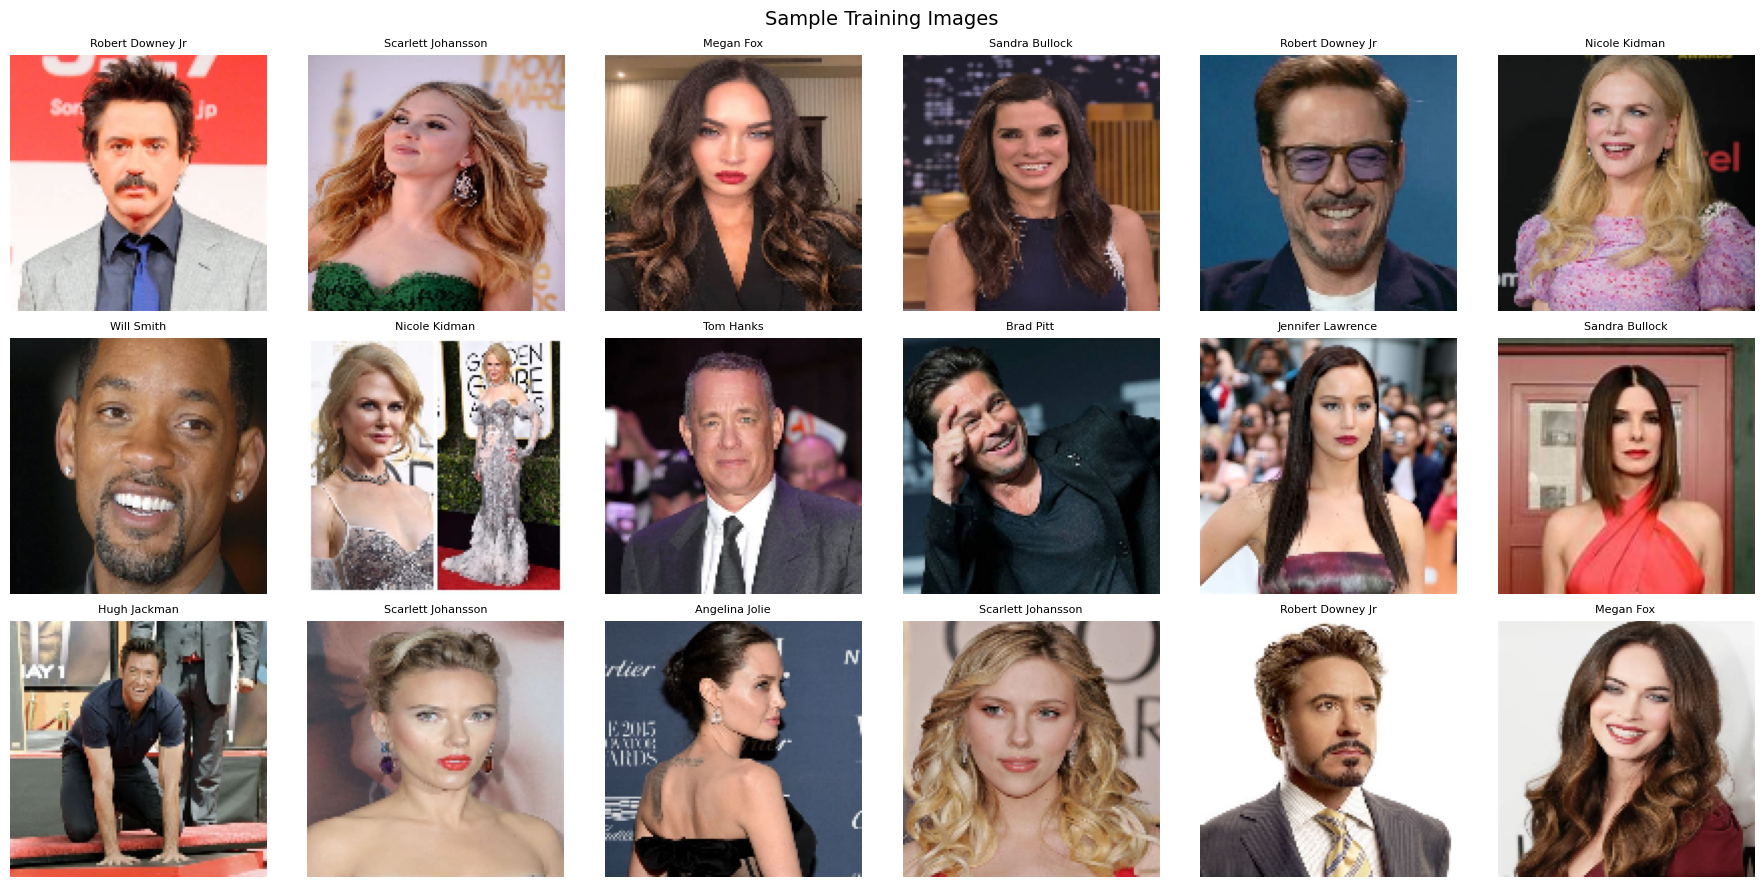

In [6]:
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for ax in axes.flat:
    idx = np.random.randint(len(images))
    ax.imshow(images[idx]); ax.set_title(labels[idx], fontsize=8); ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout(); plt.show()

## 🔄 Step 7 — Preprocess & Split

In [7]:
X = images.astype('float32') / 255.0
le = LabelEncoder()
y_enc = le.fit_transform(labels)
y = to_categorical(y_enc, num_classes=len(class_names))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y_enc, random_state=SEED)
X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.1, random_state=SEED)
print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 1296 | Val: 144 | Test: 360


## 🏗️ Step 8 — Build Model (VGG16 + Custom Head)

In [8]:
base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
for layer in base.layers[:-4]: layer.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])
model.compile(optimizer=optimizers.Adam(LEARNING_RATE),
              loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,115,089 (57.66 MB)

 Trainable params: 7,478,801 (28.53 MB)

 Non-trainable params: 7,636,288 (29.13 MB)

## 🚀 Step 9 — Train

In [13]:
datagen = ImageDataGenerator(rotation_range=15, width_shift_range=0.1,
    height_shift_range=0.1, horizontal_flip=True, zoom_range=0.1)

cb_list = [
    callbacks.EarlyStopping(patience=7, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
    callbacks.ModelCheckpoint('/content/face_best.h5', save_best_only=True, verbose=1)
]
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train)//BATCH_SIZE,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, callbacks=cb_list)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8394 - loss: 0.5222
Epoch 1: val_loss improved from None to 0.97962, saving model to /content/face_best.h5



Epoch 1: finished saving model to /content/face_best.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step - accuracy: 0.8568 - loss: 0.4913 - val_accuracy: 0.7222 - val_loss: 0.9796 - learning_rate: 5.0000e-05
Epoch 2/30
 1/40 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9375 - loss: 0.2993
Epoch 2: val_loss improved from 0.97962 to 0.97246, saving model to /content/face_best.h5



Epoch 2: finished saving model to /content/face_best.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9375 - loss: 0.2993 - val_accuracy: 0.7222 - val_loss: 0.9725 - learning_rate: 5.0000e-05
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.8646 - loss: 0.4384
Epoch 3: val_loss improved from 0.97246 to 0.95490, saving model to /content/face_best.h5



Epoch 3: finished saving model to /content/face_best.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 161ms/step - accuracy: 0.8710 - loss: 0.4429 - val_accuracy: 0.7153 - val_loss: 0.9549 - learning_rate: 5.0000e-05
Epoch 4/30
 1/40 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.9062 - loss: 0.3571
Epoch 4: val_loss improved from 0.95490 to 0.95159, saving model to /content/face_best.h5



Epoch 4: finished saving model to /content/face_best.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9062 - loss: 0.3571 - val_accuracy: 0.7361 - val_loss: 0.9516 - learning_rate: 5.0000e-05
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9015 - loss: 0.3749
Epoch 5: val_loss did not improve from 0.95159
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 159ms/step - accuracy: 0.8995 - loss: 0.3839 - val_accuracy: 0.7222 - val_loss: 1.0338 - learning_rate: 5.0000e-05
Epoch 6/30
 1/40 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.9375 - loss: 0.2813
Epoch 6: val_loss did not improve from 0.95159
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9375 - loss: 0.2813 - val_accuracy: 0.7153 - val_loss: 1.0236 - learning_rate: 5.0000e-05
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.8989 - loss: 0.3520
Epoch 7: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 7: val_loss did not improve from 0.95159
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 169ms/

...


Epoch 15: finished saving model to /content/face_best.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 158ms/step - accuracy: 0.9320 - loss: 0.2659 - val_accuracy: 0.7361 - val_loss: 0.8963 - learning_rate: 1.2500e-05
Epoch 16/30
 1/40 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9375 - loss: 0.1917
Epoch 16: val_loss improved from 0.89630 to 0.89629, saving model to /content/face_best.h5



Epoch 16: finished saving model to /content/face_best.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9375 - loss: 0.1917 - val_accuracy: 0.7361 - val_loss: 0.8963 - learning_rate: 1.2500e-05
Epoch 17/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9249 - loss: 0.2696
Epoch 17: val_loss did not improve from 0.89629
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - accuracy: 0.9383 - loss: 0.2533 - val_accuracy: 0.7361 - val_loss: 0.8974 - learning_rate: 1.2500e-05
Epoch 18/30
 1/40 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9375 - loss: 0.3211
Epoch 18: val_loss improved from 0.89629 to 0.89549, saving model to /content/face_best.h5



Epoch 18: finished saving model to /content/face_best.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9375 - loss: 0.3211 - val_accuracy: 0.7361 - val_loss: 0.8955 - learning_rate: 1.2500e-05
Epoch 19/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9519 - loss: 0.2191
Epoch 19: val_loss improved from 0.89549 to 0.87189, saving model to /content/face_best.h5



Epoch 19: finished saving model to /content/face_best.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - accuracy: 0.9509 - loss: 0.2306 - val_accuracy: 0.7500 - val_loss: 0.8719 - learning_rate: 1.2500e-05
Epoch 20/30
 1/40 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.9688 - loss: 0.1964
Epoch 20: val_loss improved from 0.87189 to 0.87150, saving model to /content/face_best.h5



Epoch 20: finished saving model to /content/face_best.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9688 - loss: 0.1964 - val_accuracy: 0.7361 - val_loss: 0.8715 - learning_rate: 1.2500e-05
Epoch 21/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.9389 - loss: 0.2491
Epoch 21: val_loss did not improve from 0.87150
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 151ms/step - accuracy: 0.9502 - loss: 0.2339 - val_accuracy: 0.7500 - val_loss: 0.8818 - learning_rate: 1.2500e-05
Epoch 22/30
 1/40 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9688 - loss: 0.2057
Epoch 22: val_loss did not improve from 0.87150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9688 - loss: 0.2057 - val_accuracy: 0.7431 - val_loss: 0.8811 - learning_rate: 1.2500e-05
Epoch 23/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9537 - loss: 0.2095
Epoch 23: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.

Epoch 23: val_loss did not improve from 0.87150
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s

## 📈 Step 10 — Training Curves

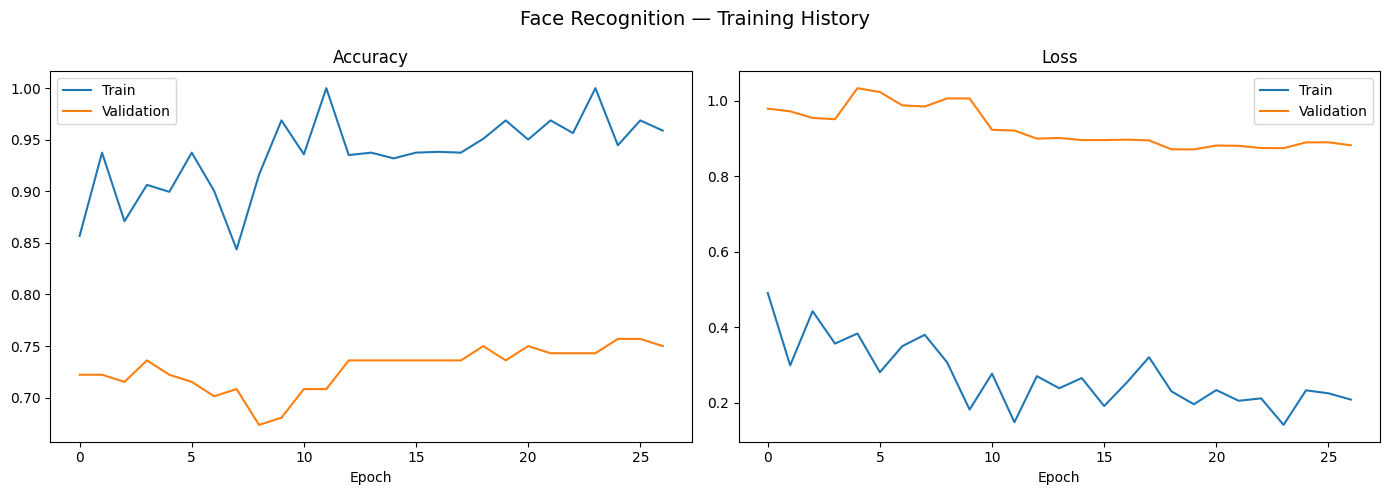

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.suptitle('Face Recognition — Training History', fontsize=14)
plt.tight_layout(); plt.show()

## 🧪 Step 11 — Evaluate

In [17]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)

train_acc = history.history['accuracy'][-1]
train_loss = history.history['loss'][-1]

print(f"✅ Train Accuracy: {train_acc*100:.2f}% | Train Loss: {train_loss:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

✅ Train Accuracy: 95.89% | Train Loss: 0.2088
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step

📊 Classification Report:
                    precision    recall  f1-score   support

    Angelina Jolie       0.80      0.60      0.69        20
         Brad Pitt       0.77      0.85      0.81        20
 Denzel Washington       0.69      0.90      0.78        20
      Hugh Jackman       0.70      0.70      0.70        20
 Jennifer Lawrence       0.33      0.40      0.36        20
       Johnny Depp       0.73      0.80      0.76        20
      Kate Winslet       0.65      0.65      0.65        20
 Leonardo DiCaprio       0.72      0.65      0.68        20
         Megan Fox       0.94      0.75      0.83        20
   Natalie Portman       0.63      0.60      0.62        20
     Nicole Kidman       0.71      0.60      0.65        20
  Robert Downey Jr       0.60      0.60      0.60        20
    Sandra Bullock       0.55      0.55      0.55        20
Scarlett Johansson       0.78      0.90      0.

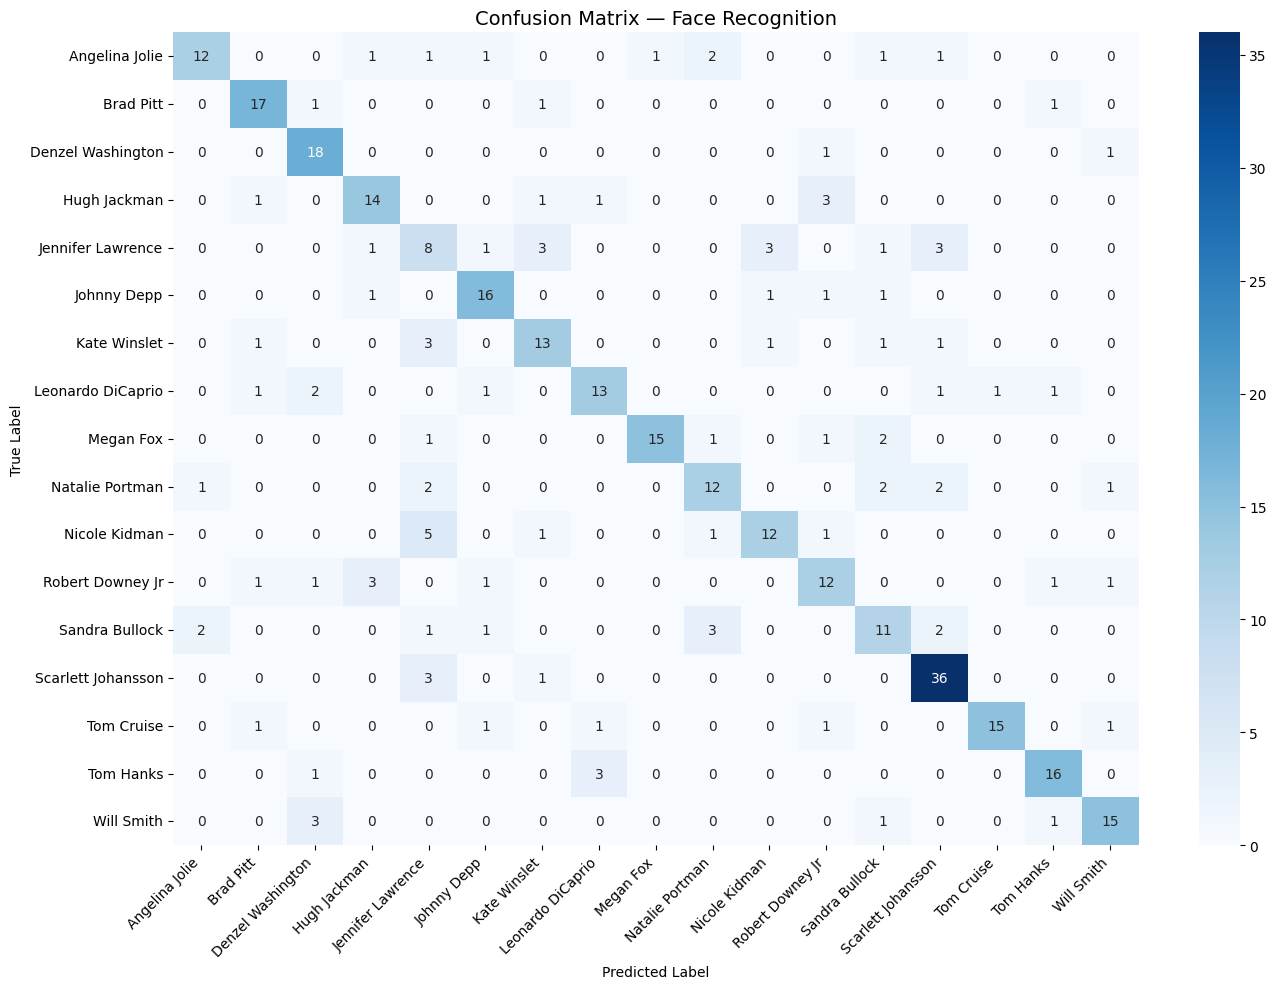

In [18]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Face Recognition', fontsize=14)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

In [19]:
model.save('/content/face_recognition_final.h5')
print("✅ Model saved to /content/face_recognition_final.h5")

✅ Model saved to /content/face_recognition_final.h5
